# DataSet - Heart Disease Prediction Dataset
# Model - KNN Classification

# Attribute Information:
-------------------------
age-age  
sex- sex  
cp- chest pain type (4 values)  
trestbps- resting blood pressure  
chol- serum cholestoral in mg/dl  
fbs- fasting blood sugar > 120 mg/dl  
restecg- resting electrocardiographic results (values 0,1,2)  
thalach- maximum heart rate achieved  
exang- exercise induced angina  
oldpeak = ST depression induced by exercise relative to rest  
slope- the slope of the peak exercise ST segment  
ca- number of major vessels (0-3) colored by flourosopy  
thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
target- 0 = low risk of heart disease, 1 = high risk of heart disease

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df=pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [76]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [77]:
df.shape

(1025, 14)

In [78]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [79]:
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [80]:
df.describe

<bound method NDFrame.describe of       age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0        

In [81]:
df['thal'].value_counts()

thal
2    544
3    410
1     64
0      7
Name: count, dtype: int64

In [82]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

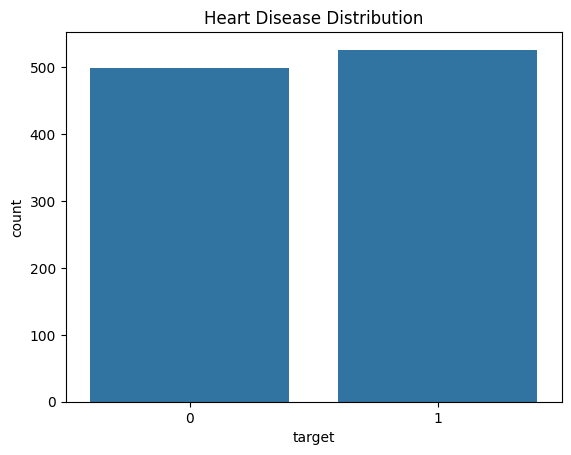

In [83]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

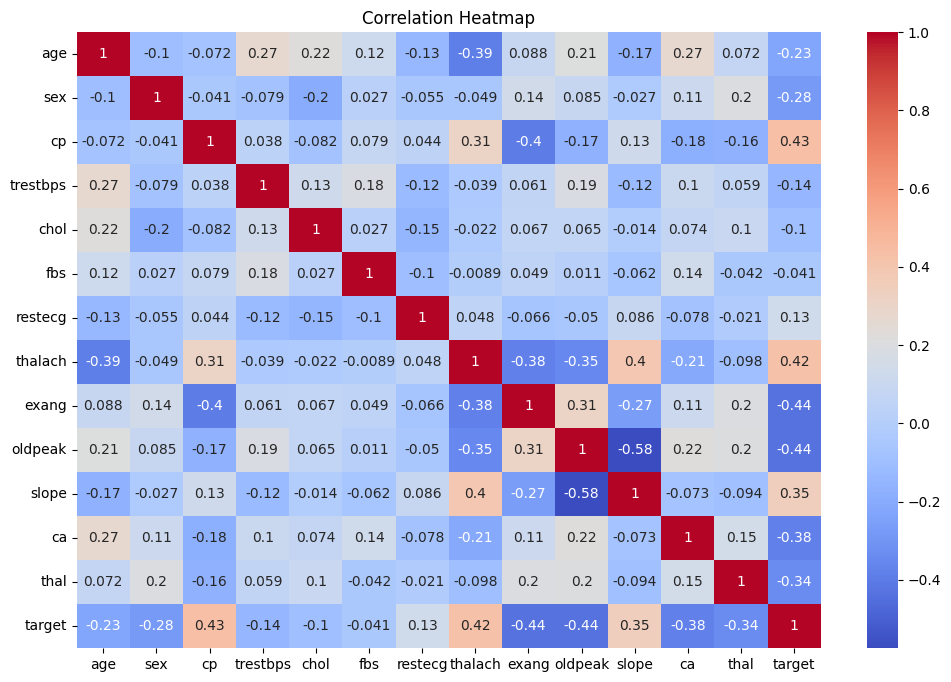

In [84]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [86]:
X=df.drop('target',axis=1)
y=df['target']

In [87]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.3, random_state=42)

In [88]:
scaler = StandardScaler()

In [89]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [90]:
#model = KNeighborsClassifier(n_neighbors=5)

In [91]:
#model.fit(X_train, y_train)

In [92]:
#y_pred = model.predict(X_test)

In [93]:
#accuracy = accuracy_score(y_test, y_pred)
#print("Accuracy: ", accuracy)

In [94]:
for k in range(1, 15):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(k, acc)

1 0.9902597402597403
2 0.9675324675324676
3 0.935064935064935
4 0.8668831168831169
5 0.8409090909090909
6 0.8538961038961039
7 0.8409090909090909
8 0.8571428571428571
9 0.8311688311688312
10 0.827922077922078
11 0.827922077922078
12 0.8409090909090909
13 0.8246753246753247
14 0.8311688311688312


## using k=3 for greater accuracy

In [95]:
model=KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
y_pred= model.predict(X_test)
acc=accuracy_score(y_test, y_pred)
print("Accuracy: ", acc)

Accuracy:  0.935064935064935


In [96]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[149,  10],
       [ 10, 139]])

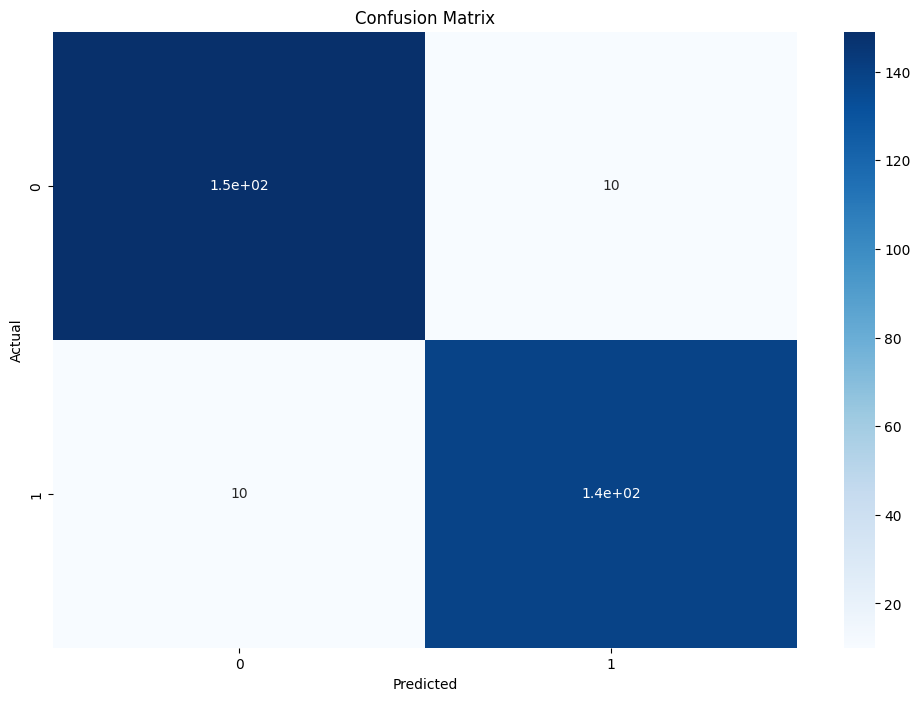

In [97]:
plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [98]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       159
           1       0.93      0.93      0.93       149

    accuracy                           0.94       308
   macro avg       0.93      0.93      0.93       308
weighted avg       0.94      0.94      0.94       308



# Prediction using input data

In [100]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [101]:
new_patient=pd.DataFrame([{
    'age':75,
    'sex':0,
    'cp':2,
    'trestbps':148,
    'chol':200,
    'fbs':0,
    'restecg':2,
    'thalach':175,
    'exang':0,
    'oldpeak':0.5,
    'slope':2,
    'ca':3,
    'thal':2,
}])

In [102]:
new_patient_scaled= scaler.transform(new_patient)
predicted_target = model.predict(new_patient_scaled)
print("Predicted Heart Disease:", predicted_target[0])

Predicted Heart Disease: 1


In [105]:
import joblib

In [106]:
joblib.dump(model, "heart_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']